# Step 1: Importing the required libraries

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Step 2: Loading the dataset

The CSV file is read into a pandas DataFrame. This is the first important step because the model and analysis cannot work without the actual data.

In [153]:
df = pd.read_csv('../data/cardio_train.csv', sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# Step 3: Dataset Inspection

To understand the dataset's structure, features, data types, and identify potential issues before preprocessing.

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [155]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## Checking for duplicate records

In [156]:
print(df.duplicated().sum())

0


## Checking unique values count in each feature

In [157]:
cat_cols = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
for col in cat_cols:
    print(f"{df[col].value_counts()}\n")

gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64

smoke
0    63831
1     6169
Name: count, dtype: int64

alco
0    66236
1     3764
Name: count, dtype: int64

active
1    56261
0    13739
Name: count, dtype: int64

cardio
0    35021
1    34979
Name: count, dtype: int64



## Checking Lowest and Highest Values for numeric columns

To identify unusual or extreme values and determine which values should be removed during data cleaning.

In [158]:
for col in ['height', 'weight', 'ap_hi', 'ap_lo']:
    print(f"\n{col}")
    print("Lowest:", sorted(df[col].unique())[:10])
    print("Highest:", sorted(df[col].unique())[-10:])


height
Lowest: [np.int64(55), np.int64(57), np.int64(59), np.int64(60), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(70)]
Highest: [np.int64(192), np.int64(193), np.int64(194), np.int64(195), np.int64(196), np.int64(197), np.int64(198), np.int64(200), np.int64(207), np.int64(250)]

weight
Lowest: [np.float64(10.0), np.float64(11.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0)]
Highest: [np.float64(170.0), np.float64(171.0), np.float64(172.0), np.float64(175.0), np.float64(177.0), np.float64(178.0), np.float64(180.0), np.float64(181.0), np.float64(183.0), np.float64(200.0)]

ap_hi
Lowest: [np.int64(-150), np.int64(-140), np.int64(-120), np.int64(-115), np.int64(-100), np.int64(1), np.int64(7), np.int64(10), np.int64(11), np.int64(12)]
Highest: [np.int64(1409), np.int64(1420), np.int64(1500), np.int64(1620), np.int64(2000), np.int64(11020), np.int64(11500)

## Checking Invalid Values

To count unrealistic values in height, weight, systolic BP, and diastolic BP before removing them during data cleaning.

In [159]:
print("Height < 100:", (df['height'] < 100).sum())
print("Height > 220:", (df['height'] > 220).sum())

print("Weight < 30:", (df['weight'] < 30).sum())
print("Weight > 200:", (df['weight'] > 200).sum())

print("Systolic BP <= 0:", (df['ap_hi'] <= 0).sum())
print("Systolic BP > 250:", (df['ap_hi'] > 250).sum())

print("Diastolic BP <= 0:", (df['ap_lo'] <= 0).sum())
print("Diastolic BP > 250:", (df['ap_lo'] > 250).sum())

Height < 100: 29
Height > 220: 1
Weight < 30: 7
Weight > 200: 0
Systolic BP <= 0: 7
Systolic BP > 250: 40
Diastolic BP <= 0: 22
Diastolic BP > 250: 953


## Height Analysis

### Height Boxplot

To visualize the distribution of height and identify potential outliers.

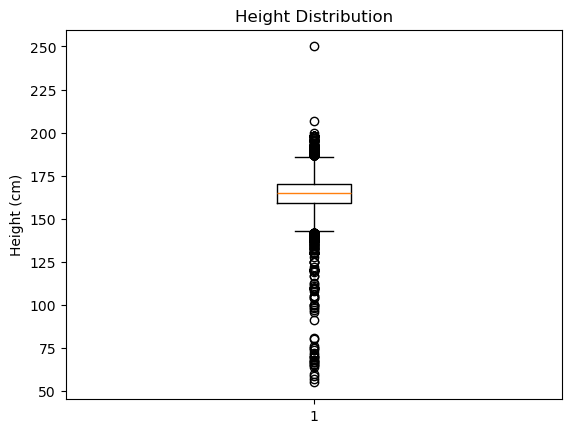

In [ ]:
plt.boxplot(df['height'])
plt.title('Height Distribution')
plt.ylabel('Height (cm)')
plt.show()

### Height Distribution 

To visualize the distribution of height and identify its frequency, spread, and potential unusual values.

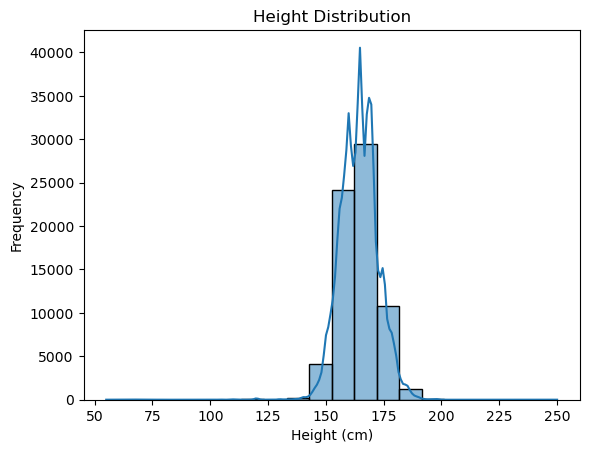

In [161]:
sns.histplot(df['height'], bins=20, kde=True, edgecolor='black')

plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')

plt.show()

### IQR Outlier Detection for Height

To calculate the lower and upper fences and identify potential height outliers using the IQR method.

In [162]:
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 159.0
Q3: 170.0
IQR: 11.0
Lower fence: 142.5
Upper fence: 186.5


### Height Outlier Check

To identify records with unrealistic height values below 100 cm or above 220 cm.

In [163]:
df[(df['height'] < 100) | (df['height'] > 220)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1,1,0,0,1,0
6486,9223,21220,1,250,86.0,140,100,3,1,0,0,1,1
7598,10843,14661,2,70,72.0,120,8,1,1,0,0,1,0
8171,11662,17646,2,97,170.0,160,100,1,1,1,0,1,1
12770,18218,19594,1,75,168.0,120,80,1,1,1,0,1,1
13265,18928,22456,2,71,68.0,120,80,3,1,0,0,1,0
14323,20459,22005,1,67,57.0,120,90,1,1,0,0,1,1
15167,21686,15812,1,70,68.0,120,80,1,1,0,0,0,0
16699,23859,19680,2,74,98.0,140,90,1,1,0,0,1,1
17277,24690,17530,1,98,45.0,12,80,1,1,0,0,1,0


## Weight Analysis

### Weight Boxplot

To visualize the weight distribution and identify potential outliers.

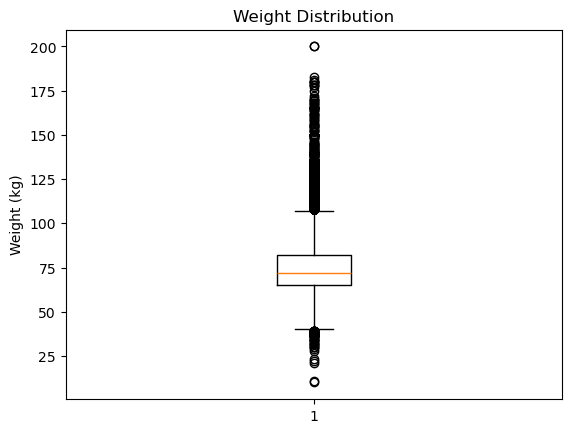

In [164]:
# Weight

plt.boxplot(df['weight'])
plt.title('Weight Distribution')
plt.ylabel('Weight (kg)')
plt.show()

### Weight Distribution

To visualize the weight distribution and identify its frequency, spread, and potential unusual values.

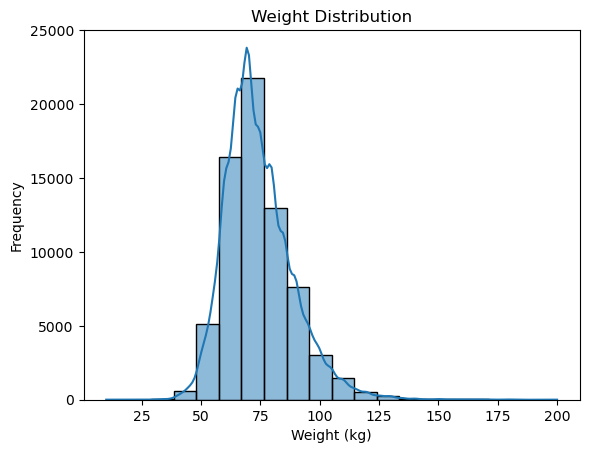

In [165]:
sns.histplot(df['weight'], bins=20, kde=True, edgecolor='black')

plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')

plt.show()

### Weight IQR Analysis

To calculate the IQR and determine the lower and upper limits for identifying weight outliers.

In [166]:
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 65.0
Q3: 82.0
IQR: 17.0
Lower fence: 39.5
Upper fence: 107.5


### Weight Outlier Check

To identify records with unrealistic weight values below 30 kg or above 200 kg.

In [167]:
df[(df['weight'] < 30) | (df['weight'] > 200)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
26806,38312,23284,1,157,23.0,110,80,1,1,0,0,1,0
29488,42156,20408,2,177,22.0,120,80,1,1,1,1,1,0
33817,48318,21582,2,178,11.0,130,90,1,1,0,0,1,1
34276,48976,14664,2,128,28.0,120,80,1,1,0,0,1,0
57858,82567,18804,2,165,10.0,180,1100,2,2,0,0,1,1
60188,85931,21855,1,162,21.0,120,80,2,1,0,0,1,1
60699,86650,18875,1,171,29.0,110,70,2,1,0,0,1,1


## Systolic BP Analysis

### Systolic BP Boxplot

To visualize the systolic blood pressure distribution and identify potential outliers.


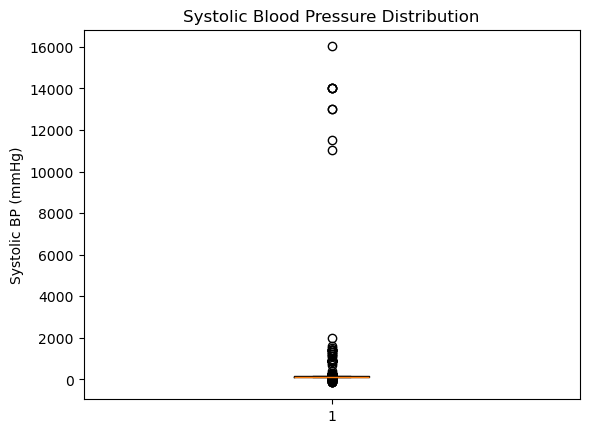

In [168]:
plt.boxplot(df['ap_hi'])
plt.title('Systolic Blood Pressure Distribution')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Systolic BP Distribution

To visualize the systolic blood pressure distribution and identify its frequency, spread, and potential unusual values.

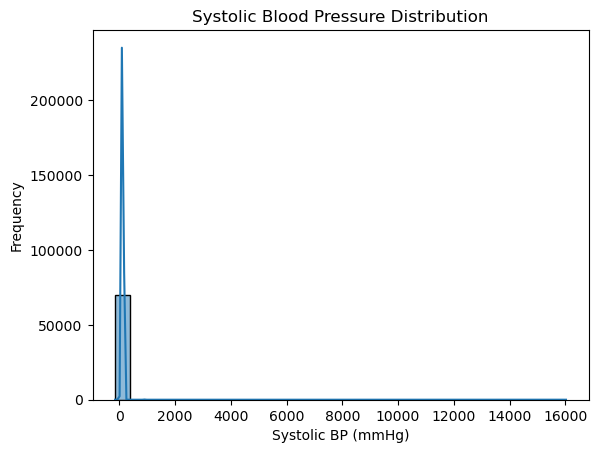

In [169]:
sns.histplot(df['ap_hi'], bins=30, kde=True, edgecolor='black')

plt.title('Systolic Blood Pressure Distribution')
plt.xlabel('Systolic BP (mmHg)')
plt.ylabel('Frequency')

plt.show()

### Systolic BP IQR Analysis

To calculate the IQR and determine the lower and upper limits for identifying systolic blood pressure outliers.

In [170]:
Q1 = df['ap_hi'].quantile(0.25)
Q3 = df['ap_hi'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower fence: 90.0
Upper fence: 170.0


### Systolic BP Outlier Check

To identify records with invalid systolic blood pressure values at or below 0 or above 250 mmHg.

In [171]:
df[(df['ap_hi'] <= 0) | (df['ap_hi'] > 250)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1876,2654,15116,1,160,60.0,902,60,1,1,0,0,1,0
2014,2845,22712,2,167,59.0,906,0,1,1,0,0,1,0
4607,6525,15281,1,165,78.0,-100,80,2,1,0,0,1,0
4817,6822,14425,1,168,63.0,909,60,2,1,0,0,1,0
7763,11089,21032,1,175,80.0,11500,90,1,1,0,0,1,1
8915,12710,18870,1,164,75.0,1420,80,2,1,0,0,1,1
9557,13616,22659,1,155,87.0,701,110,1,1,0,0,1,1
13895,19827,15996,1,168,72.0,1500,80,1,1,0,0,1,1
16021,22881,22108,2,161,90.0,-115,70,1,1,0,0,1,0
17713,25314,22398,2,163,50.0,907,70,3,3,0,0,1,1


## Diastolic BP Analysis

### Diastolic BP Boxplot

To visualize the diastolic blood pressure distribution and identify potential outliers.


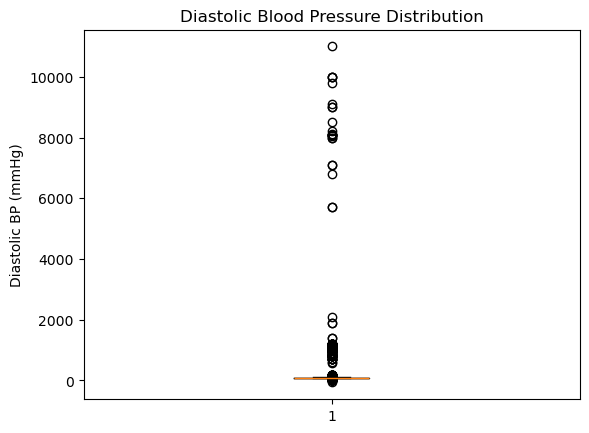

In [ ]:
plt.boxplot(df['ap_lo'])
plt.title('Diastolic Blood Pressure Distribution')
plt.ylabel('Diastolic BP (mmHg)')
plt.show()

### Diastolic BP Distribution

To visualize the diastolic blood pressure distribution and identify its frequency, spread, and potential unusual values.

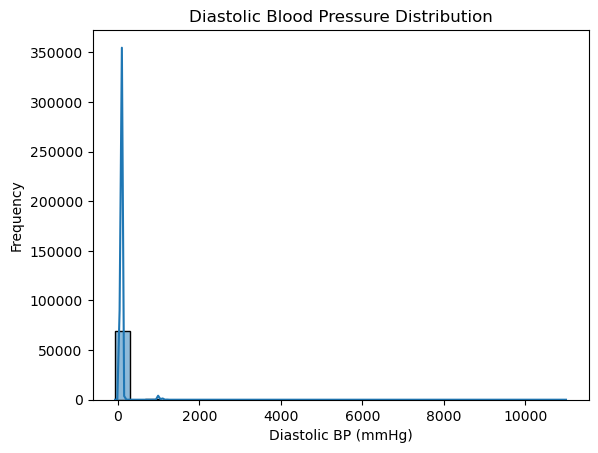

In [173]:
sns.histplot(df['ap_lo'], bins=30, kde=True, edgecolor='black')

plt.title('Diastolic Blood Pressure Distribution')
plt.xlabel('Diastolic BP (mmHg)')
plt.ylabel('Frequency')

plt.show()

### Diastolic BP IQR Analysis

To calculate the IQR and determine the lower and upper limits for identifying diastolic blood pressure outliers.


In [174]:
Q1 = df['ap_lo'].quantile(0.25)
Q3 = df['ap_lo'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", Q1 - 1.5 * IQR)
print("Upper Fence:", Q3 + 1.5 * IQR)

Q1: 80.0
Q3: 90.0
IQR: 10.0
Lower Fence: 65.0
Upper Fence: 105.0


### Diastolic BP Outlier Check

To identify records with invalid diastolic blood pressure values below 0 or at or above 250 mmHg.

In [175]:
df[(df['ap_lo'] < 0) | (df['ap_lo'] >= 250)].head(30)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1
345,482,18704,1,154,81.0,140,1000,2,1,0,0,1,1
473,680,15226,1,150,95.0,150,1033,1,1,0,0,1,1
559,805,20430,2,173,101.0,200,1000,1,1,0,0,1,1
613,886,18963,1,165,92.0,140,1000,1,1,1,0,1,1
649,928,18190,1,166,57.0,190,1100,1,1,0,0,1,1
653,932,21842,1,156,72.0,180,1000,2,1,0,0,0,1


## BP Relationship Check

To count records where systolic blood pressure is less than or equal to diastolic blood pressure, which indicates an invalid BP relationship.


In [176]:
print((df['ap_hi'] <= df['ap_lo']).sum())

1236


In [177]:
df[df['ap_hi'] <= df['ap_lo']][['ap_hi', 'ap_lo']].head(30)

,ap_hi,ap_lo
228,160,1100
241,160,1000
260,140,800
329,160,1000
345,140,1000
473,150,1033
474,120,150
559,200,1000
567,14,90
613,140,1000


# Step 4: Cleaning the data

To clean the dataset by improving column names, converting age into years, and removing invalid or unrealistic values. This helps ensure the data is accurate and suitable for model training.


## Creating a Clean Dataset

To create a copy of the original dataset so that data cleaning can be performed without modifying the original data.


In [ ]:
clean_df = df.copy()
clean_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


## Renaming Columns

To rename abbreviated column names into clear, descriptive names that make the dataset easier to understand and work with.

In [ ]:
clean_df.rename(columns={
    'ap_hi': 'systolic_bp',
    'ap_lo': 'diastolic_bp',
    'cholesterol': 'cholesterol_level',
    'gluc': 'glucose_level',
    'smoke': 'smoking',
    'alco': 'alcohol',
    'active': 'physical_activity',
    'cardio': 'cardiovascular_disease'
}, inplace=True)

## Converting Age to Years

To convert age from days into years and round it to the nearest whole number for easier interpretation.

In [181]:
clean_df['age'] = (clean_df['age'] / 365.25).round().astype(int)
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


## Removing Invalid Values

To remove unrealistic height, weight, systolic BP, and diastolic BP values based on domain knowledge and statistical analysis, improving the quality of the dataset for model training.


In [182]:
# removing outliers based on realistic domain knowledge and statistical analysis

clean_df = clean_df[(clean_df['height'] >= 100) & (clean_df['height'] <= 220)]
clean_df = clean_df[clean_df['weight'] >= 30]
clean_df = clean_df[(clean_df['systolic_bp'] > 0) & (clean_df['systolic_bp'] <= 250)]
clean_df = clean_df[(clean_df['diastolic_bp'] > 0) & (clean_df['diastolic_bp'] < 250)]


In [183]:
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


## Validating Blood Pressure Relationship

To check for records where systolic BP is less than or equal to diastolic BP, which represents an invalid blood pressure relationship after removing invalid inputs,

In [184]:
print((clean_df['systolic_bp'] <= clean_df['diastolic_bp']).sum())

274


## Removing Invalid BP Relationships

To remove records where systolic blood pressure is not greater than diastolic blood pressure, ensuring a valid blood pressure relationship.


In [185]:
clean_df = clean_df[clean_df['systolic_bp'] > clean_df['diastolic_bp']]
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


# Step 5: Preparing Data for Machine Learning

To select relevant features, remove unnecessary columns, and prepare the cleaned dataset for model training and testing.

## Feature Correlation Analysis

To examine how strongly each feature is correlated with cardiovascular disease and identify potentially useful features for the model.

In [186]:
clean_df.drop(columns='id').corr()['cardiovascular_disease'].sort_values(ascending=False)

cardiovascular_disease    1.000000
systolic_bp               0.427491
diastolic_bp              0.335916
age                       0.239005
cholesterol_level         0.221492
weight                    0.179800
glucose_level             0.089535
gender                    0.007243
alcohol                  -0.008583
height                   -0.012030
smoking                  -0.016325
physical_activity        -0.037525
Name: cardiovascular_disease, dtype: float64

## Correlation Heatmap

To visualize the relationships between all numerical features and identify features that are strongly correlated with each other or cardiovascular disease.

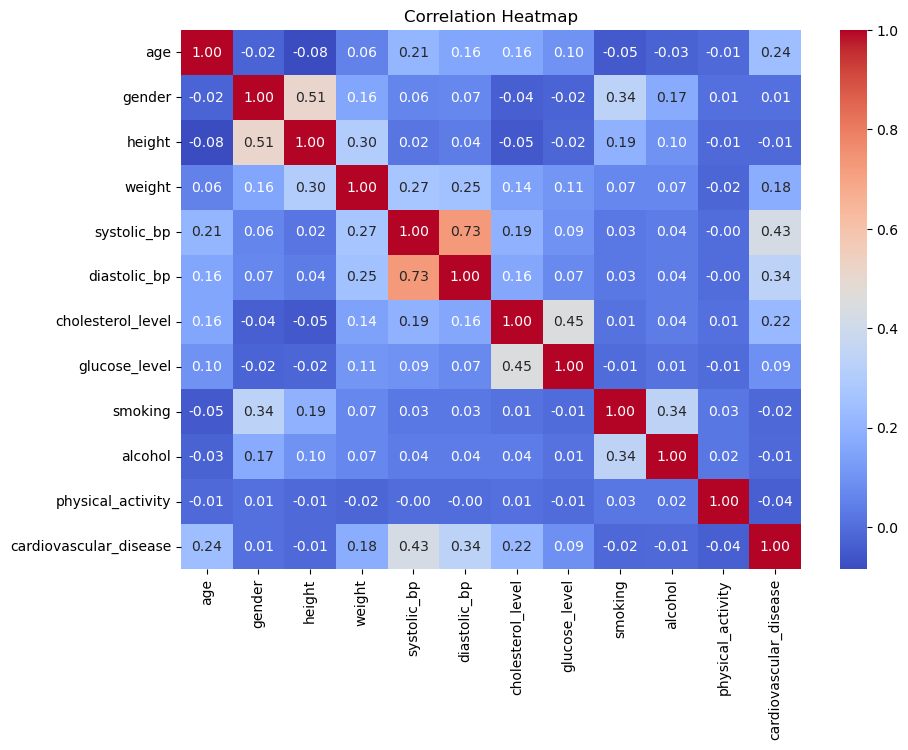

In [187]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    clean_df.drop(columns='id').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## Mann-Whitney U Test

To compare numerical features between patients with and without cardiovascular disease and determine whether their distributions differ significantly.


In [188]:
from scipy.stats import mannwhitneyu

numerical_features = [
    'age',
    'height',
    'weight',
    'systolic_bp',
    'diastolic_bp'
]

for feature in numerical_features:
    group_0 = clean_df[clean_df['cardiovascular_disease'] == 0][feature]
    group_1 = clean_df[clean_df['cardiovascular_disease'] == 1][feature]

    stat, p_value = mannwhitneyu(group_0, group_1)

    print(f"{feature}")
    print(f"U statistic: {stat:.2f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")
    print("-" * 40)

age
U statistic: 428673236.00
p-value: 0.000000
Significant: Yes
----------------------------------------
height
U statistic: 597922984.00
p-value: 0.001117
Significant: Yes
----------------------------------------
weight
U statistic: 466653229.00
p-value: 0.000000
Significant: Yes
----------------------------------------
systolic_bp
U statistic: 293288029.50
p-value: 0.000000
Significant: Yes
----------------------------------------
diastolic_bp
U statistic: 364779254.00
p-value: 0.000000
Significant: Yes
----------------------------------------


## Chi-Square Test

To determine whether each categorical feature has a statistically significant association with cardiovascular disease.

In [189]:
from scipy.stats import chi2_contingency

categorical_features = [
    'gender',
    'cholesterol_level',
    'glucose_level',
    'smoking',
    'alcohol',
    'physical_activity'
]

for feature in categorical_features:

    # Create a frequency table
    contingency_table = pd.crosstab(
        clean_df[feature],
        clean_df['cardiovascular_disease']
    )

    # Perform Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(feature)
    print(f"Chi-square statistic: {chi2:.2f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")
    print("-" * 40)

gender
Chi-square statistic: 3.57
p-value: 0.058735
Significant: No
----------------------------------------
cholesterol_level
Chi-square statistic: 3369.33
p-value: 0.000000
Significant: Yes
----------------------------------------
glucose_level
Chi-square statistic: 578.97
p-value: 0.000000
Significant: Yes
----------------------------------------
smoking
Chi-square statistic: 18.19
p-value: 0.000020
Significant: Yes
----------------------------------------
alcohol
Chi-square statistic: 4.98
p-value: 0.025605
Significant: Yes
----------------------------------------
physical_activity
Chi-square statistic: 96.52
p-value: 0.000000
Significant: Yes
----------------------------------------


## Cramér's V Analysis

To measure the strength of association between each categorical feature and cardiovascular disease after the Chi-Square test.


In [190]:
from scipy.stats import chi2_contingency

categorical_features = [
    'gender',
    'cholesterol_level',
    'glucose_level',
    'smoking',
    'alcohol',
    'physical_activity'
]

for feature in categorical_features:

    contingency_table = pd.crosstab(
        clean_df[feature],
        clean_df['cardiovascular_disease']
    )

    chi2, _, _, _ = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    min_dimension = min(contingency_table.shape) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dimension)
    )

    print(f"{feature}: Cramér's V = {cramers_v:.3f}")

gender: Cramér's V = 0.007
cholesterol_level: Cramér's V = 0.221
glucose_level: Cramér's V = 0.092
smoking: Cramér's V = 0.016
alcohol: Cramér's V = 0.009
physical_activity: Cramér's V = 0.037


# Step 6: Data Preprocessing

To prepare the cleaned data for machine learning by separating features and target, splitting the data into training and testing sets, and applying necessary preprocessing steps.


## Splitting Features and Target

To separate the input features (x) from the cardiovascular disease target variable (y), preparing the data for model training and prediction.


In [191]:
x = clean_df.drop(columns=['id', 'gender', 'cardiovascular_disease'])
y = clean_df['cardiovascular_disease']

## Train-test split

The dataset is divided into training and test sets. This allows the model to learn from one section and be checked on another section.

In [192]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Scaling the features

KNN is sensitive to the scale of values. Min-Max scaling brings all features to a similar range so the model can compare them fairly.

In [193]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()

x_train_minmax = scaler_minmax.fit_transform(x_train)
x_test_minmax = scaler_minmax.transform(x_test)

# Step 7: Building the KNN Model

To build a K-Nearest Neighbors classification model that learns from the training data and predicts whether a person has cardiovascular disease.

## Selecting the best K value

The value of K is important in KNN. Different K values are tested, and the value with the best cross-validation accuracy is chosen.

In [194]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = range(3, 31, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_minmax, y_train, cv=5)
    cv_scores.append(scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]

print("Best K:", best_k)
print("Best CV Accuracy:", max(cv_scores))

Best K: 29
Best CV Accuracy: 0.7252275209319257


## Training the model

After selecting the best K value, the KNN classifier is trained on the training data. The model learns the relationship between the features and the disease label.

In [195]:
knn = KNeighborsClassifier(
    n_neighbors=29,
    weights='uniform'
)

knn.fit(x_train_minmax, y_train)

,n_neighbors,29
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Making predictions

Once the model is trained, it predicts the disease status for the test data. This shows how well the model works on unseen examples.

In [196]:
y_pred = knn.predict(x_test_minmax)

# Step 8: Evaluating the KNN Model

To evaluate the model using accuracy, confusion matrix, and classification report to measure prediction performance and identify classification errors.

## Calculating Test Accuracy

To calculate the model’s accuracy on the test data by comparing the actual and predicted labels.

In [197]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7227520931925737


## Confusion Matrix

To visualize the model’s correct and incorrect predictions by comparing the actual and predicted cardiovascular disease classes.

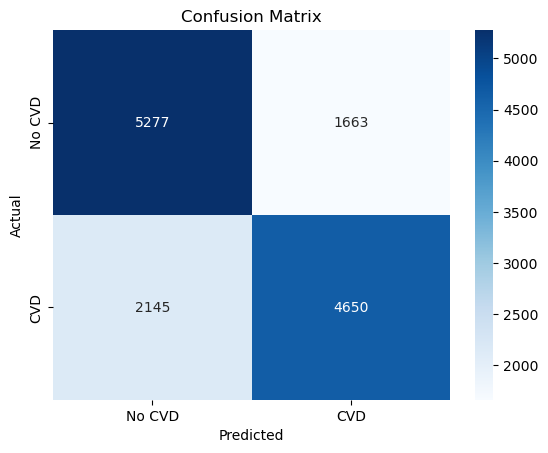

In [198]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No CVD', 'CVD'],
    yticklabels=['No CVD', 'CVD']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Classification Report

To evaluate the model using precision, recall, F1-score, and support for each class.

In [199]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.76      0.73      6940
           1       0.74      0.68      0.71      6795

    accuracy                           0.72     13735
   macro avg       0.72      0.72      0.72     13735
weighted avg       0.72      0.72      0.72     13735

